## Student Performance Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load the dataset
df = pd.read_excel('students_scores_5000.xlsx')

# Display the first 5 rows
df.head()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,1,23,85,57,98,9.7,1
1,2,20,81,52,53,2.2,1
2,3,21,38,35,87,6.1,1
3,4,23,41,69,86,8.2,1
4,5,19,69,98,81,5.7,1


# Data Integrity & Summary Statistics
We need to check if there are any missing values and understand the distribution of the scores.

In [15]:
# Check for missing values and data types
print(df.info())

# Summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     5000 non-null   int64  
 1   Age            5000 non-null   int64  
 2   Math_Score     5000 non-null   int64  
 3   Science_Score  5000 non-null   int64  
 4   English_Score  5000 non-null   int64  
 5   Hours_Studied  5000 non-null   float64
 6   Pass_Fail      5000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 273.6 KB
None


,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.468400,67.352000,66.858000,67.234200,5.584880,0.935800
std,1443.520003,2.276673,18.703745,18.781682,18.848247,2.597867,0.245133
min,1.000000,17.000000,35.000000,35.000000,35.000000,1.000000,0.000000
25%,1250.750000,18.000000,51.000000,51.000000,51.000000,3.400000,1.000000
50%,2500.500000,20.000000,67.000000,67.000000,67.000000,5.600000,1.000000
75%,3750.250000,22.000000,84.000000,83.000000,84.000000,7.800000,1.000000
max,5000.000000,24.000000,99.000000,99.000000,99.000000,10.000000,1.000000


Intuition: The info() method checks if the data is "clean" (no null values). The describe() method acts like a "Pulse Check." It calculates the Mean (average score), Standard Deviation (how much scores vary), and Percentiles. If the mean Math score is 65 but the 75th percentile is 85, you know the top quarter of the class is doing significantly better than the rest.

# Correlation Heatmap
This operation reveals which factors (like Study Hours) actually drive the student's success.

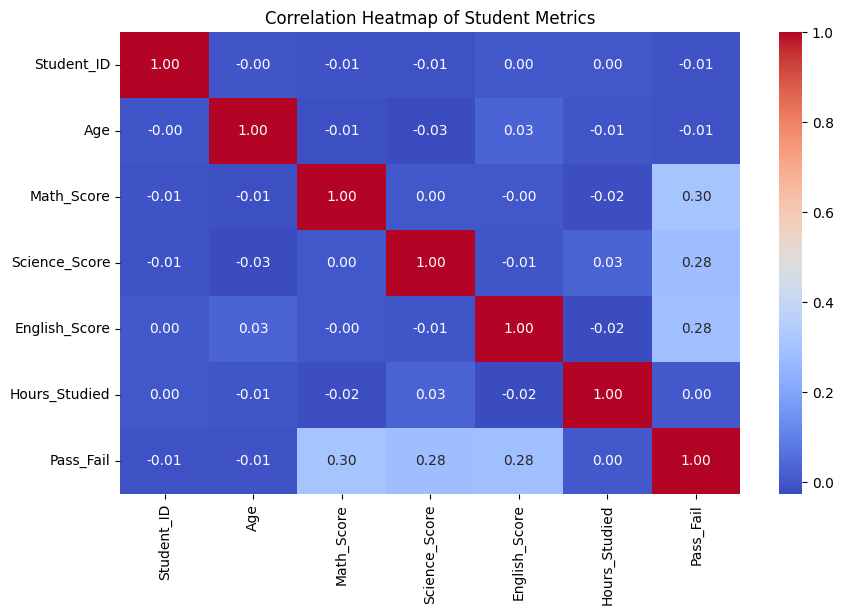

In [16]:
# Calculate correlation matrix
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Student Metrics')
plt.show()

Intuition: We are looking for a relationship between $X$ (Hours Studied) and $Y$ (Scores). A correlation near 1.0 indicates a strong positive relationship. If Hours_Studied has a high correlation with Pass_Fail, it confirms that effort is a primary predictor of success in this dataset.

# Performance Analysis (Pass vs. Fail)
We aggregate the data to see the "average profile" of a student who passes versus one who fails.

In [17]:
# Group by Pass_Fail and calculate averages
performance_analysis = df.groupby('Pass_Fail')[['Math_Score', 'Science_Score', 'English_Score', 'Hours_Studied']].mean()
performance_analysis

,Math_Score,Science_Score,English_Score,Hours_Studied
Pass_Fail,,,,
0,45.626168,46.769470,46.744548,5.571651
1,68.842488,68.236162,68.639880,5.585788


# Perform analysis of Pass And Fail Visuaization

performance_analysis visualization


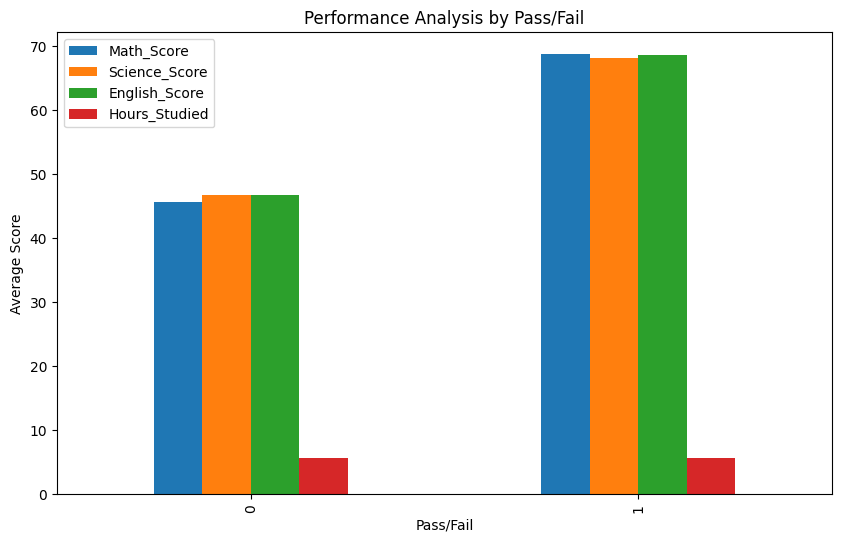

In [18]:
print("performance_analysis visualization")

# Visualize the performance analysis
performance_analysis.plot(kind='bar', figsize=(10, 6))
plt.title('Performance Analysis by Pass/Fail')
plt.xlabel('Pass/Fail')
plt.ylabel('Average Score')
plt.show()

# Score Distribution Visualization
Let's look at the density of the scores to see where the majority of students fall.

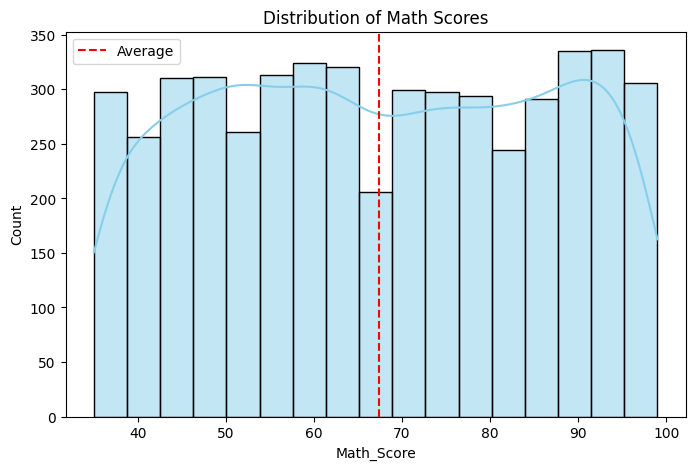

In [19]:
# Distribution of Math Scores
plt.figure(figsize=(8, 5))
sns.histplot(df['Math_Score'], kde=True, color='skyblue')
plt.axvline(df['Math_Score'].mean(), color='red', linestyle='--', label='Average')
plt.title('Distribution of Math Scores')
plt.legend()
plt.show()

Intuition: The Histogram shows us the "Shape" of the class. If it looks like a Bell Curve (Normal Distribution), most students are average. If it is "Bimodal" (two peaks), it means the class is split between very high achievers and those struggling, with very few in the middle.

# Identifying Outliers
Finally, we look for "High Efficiency" students—those who scored high with very little study time.

In [20]:
# Filtering students with high scores (>90) but low study hours (<3)
efficient_students = df[(df['Math_Score'] > 90) & (df['Hours_Studied'] < 3)]
efficient_students.head()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
79,80,20,99,88,46,1.8,1
115,116,20,91,85,35,1.1,1
219,220,23,94,95,39,2.3,1
239,240,24,91,81,72,1.6,1
279,280,18,91,85,85,1.7,1


Intuition: In data science, this is called Anomalous Detection. These data points represent exceptions to the rule. Finding these students helps us understand if some subjects are "common knowledge" or if certain students have a higher baseline aptitude.

# Performance Distribution
Are most students average, or is there a huge gap?

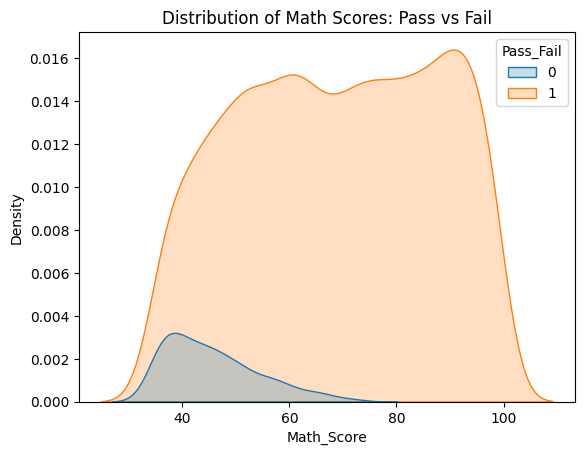

In [21]:
# Distribution of Scores
sns.kdeplot(data=df, x='Math_Score', hue='Pass_Fail', fill=True)
plt.title('Distribution of Math Scores: Pass vs Fail')
plt.show()

Intuition: This shows the overlap. If the "Fail" curve and "Pass" curve are far apart, the test was a clear divider. If they overlap heavily, it suggests that math score alone wasn't the only factor in passing.

# Categorical Analysis (Age Groups)
Does age play a role in academic success?

C:\Users\DELL\AppData\Local\Temp\ipykernel_11888\1509290786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age', y='Math_Score', palette='Set2')


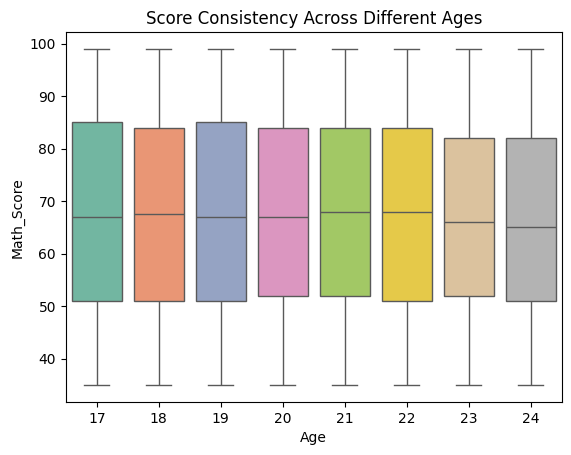

In [22]:
# Boxplot of Math Scores by Age
sns.boxplot(data=df, x='Age', y='Math_Score', palette='Set2')
plt.title('Score Consistency Across Different Ages')
plt.show()

Intuition: This measures consistency. If one age group has a very "short" box, they are all scoring similarly. If the box is "tall," that age group has very unpredictable performance levels.

# Pass/Fail Ratio
The final verdict of the dataset.

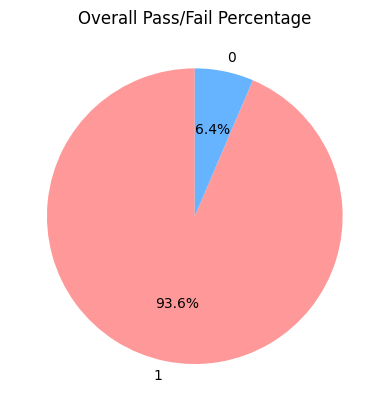

In [23]:
# Pie Chart of Pass vs Fail
df['Pass_Fail'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Overall Pass/Fail Percentage')
plt.ylabel('')
plt.show()

Intuition: This provides the bottom line. Out of 5,000 students, what is the survival rate? It’s the ultimate KPI (Key Performance Indicator) for this analysis.

# Identifying Outliers (Boxplot Analysis)
Finding the students who don't fit the pattern.

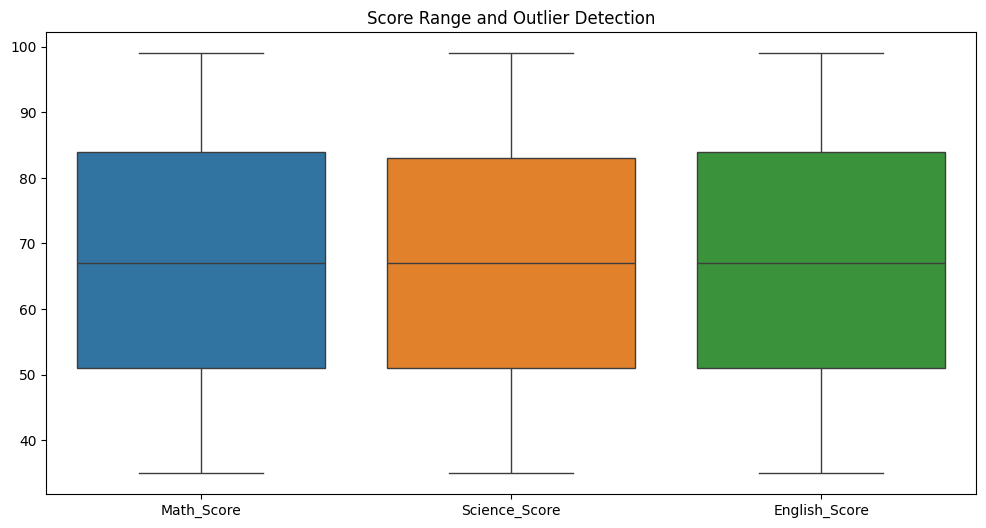

In [24]:
# Boxplot for subject scores
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['Math_Score', 'Science_Score', 'English_Score']])
plt.title("Score Range and Outlier Detection")
plt.show()

Intuition: A Boxplot visualizes the "interquartile range." The little dots outside the whiskers are Outliers—students who performed significantly better or worse than the 5,000-person norm.

# Correlation Analysis
How much does studying actually affect the outcome?

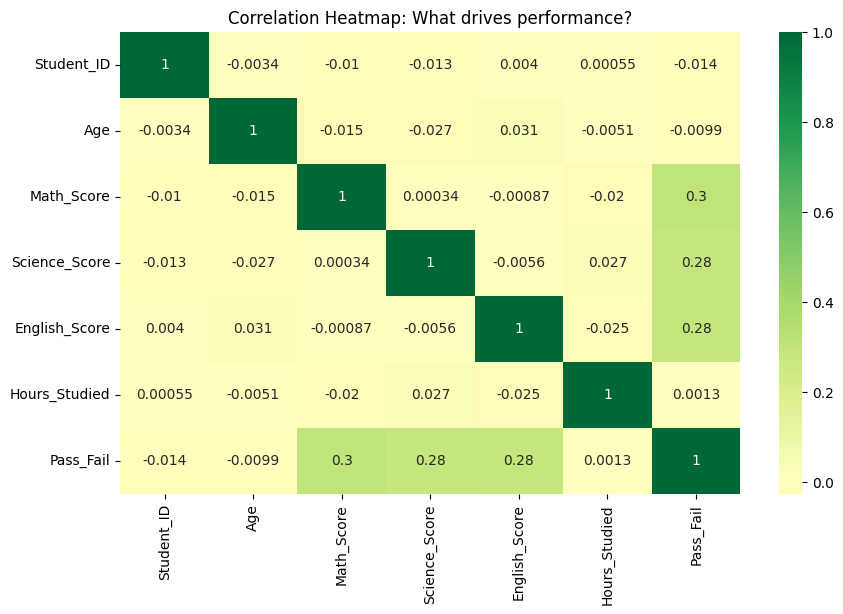

In [25]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap: What drives performance?')
plt.show()

Intuition: We are looking for patterns. A high positive number (close to 1) between Hours_Studied and Pass_Fail proves that more time spent hitting the books directly leads to better results. It turns raw data into a "cause-and-effect" map.